In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [5]:
# Replace this with your own image filename
image_path = "no_leaf1.jpg"

# Load image using OpenCV
image_bgr = cv2.imread(image_path)

# Check if the image loaded correctly
if image_bgr is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

# Convert BGR (OpenCV default) to RGB for plotting
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print("Image loaded successfully.")
print("Image shape:", image_rgb.shape)

Image loaded successfully.
Image shape: (4080, 3060, 3)


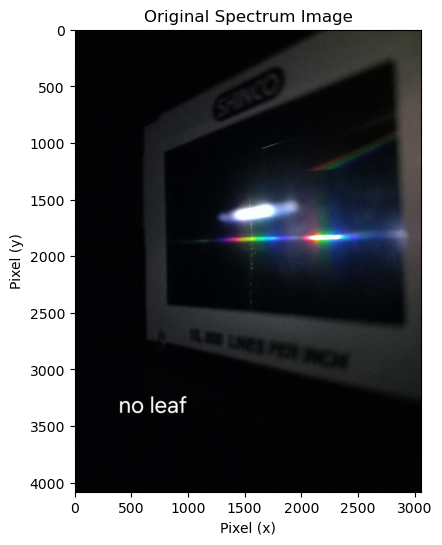

In [7]:
plt.figure(figsize=(12, 6))
plt.imshow(image_rgb)
plt.title("Original Spectrum Image")
plt.xlabel("Pixel (x)")
plt.ylabel("Pixel (y)")
plt.show()

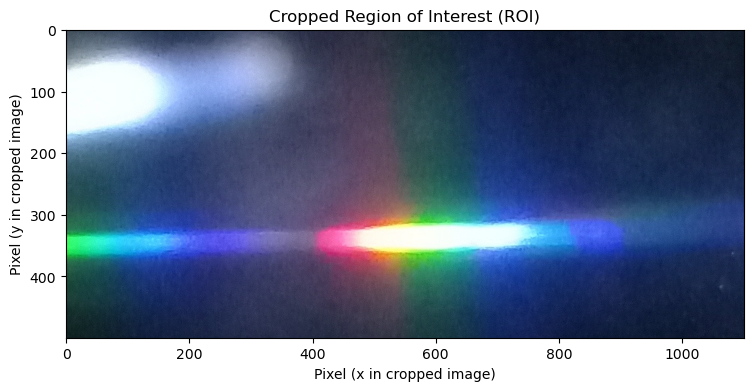

In [8]:
# Example crop values
# Adjust these to match your image
x_start = 1600
x_end   = 2700
y_start = 1500
y_end   = 2000

roi = image_rgb[y_start:y_end, x_start:x_end]

plt.figure(figsize=(12, 4))
plt.imshow(roi)
plt.title("Cropped Region of Interest (ROI)")
plt.xlabel("Pixel (x in cropped image)")
plt.ylabel("Pixel (y in cropped image)")
plt.show()

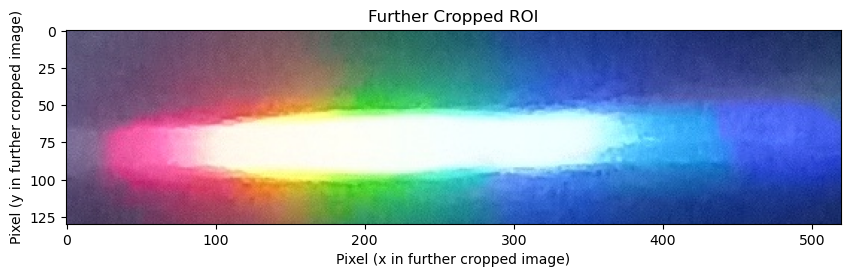

In [9]:
# Further crop the existing ROI
x2_start = 380
x2_end   = 900
y2_start = 260
y2_end   = 390

roi2 = roi[y2_start:y2_end, x2_start:x2_end]

plt.figure(figsize=(10, 4))
plt.imshow(roi2)
plt.title("Further Cropped ROI")
plt.xlabel("Pixel (x in further cropped image)")
plt.ylabel("Pixel (y in further cropped image)")
plt.show()

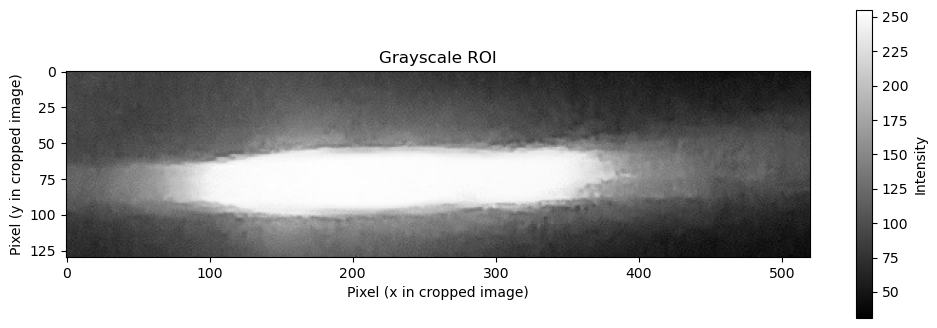

In [10]:
roi_gray = cv2.cvtColor(roi2, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(12, 4))
plt.imshow(roi_gray, cmap="gray")
plt.title("Grayscale ROI")
plt.xlabel("Pixel (x in cropped image)")
plt.ylabel("Pixel (y in cropped image)")
plt.colorbar(label="Intensity")
plt.show()

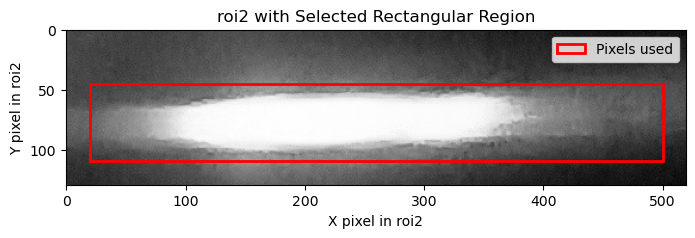

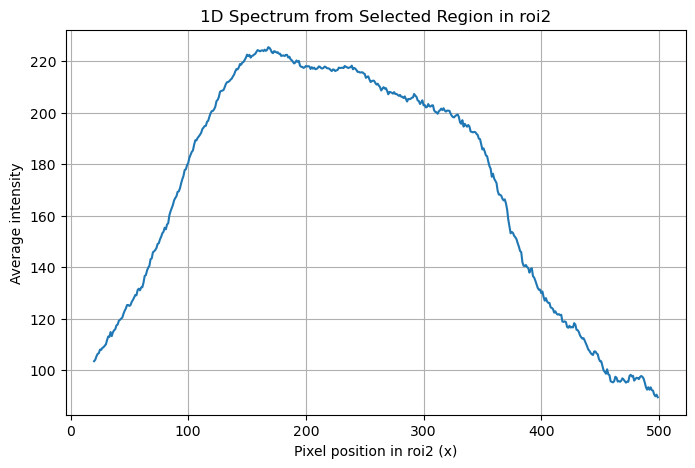

In [12]:
 import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import cv2

roi2_gray = cv2.cvtColor(roi2, cv2.COLOR_RGB2GRAY)

y_start_line = 45
y_end_line   = 110

x_start_line = 20
x_end_line   = 500
selected_region = roi2_gray[y_start_line:y_end_line, x_start_line:x_end_line]
spectrum_1d = np.mean(selected_region, axis=0)
x_pixels = np.arange(x_start_line, x_end_line)

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(roi2_gray, cmap="gray")

rect = Rectangle(
    (x_start_line, y_start_line),
    x_end_line - x_start_line,
    y_end_line - y_start_line,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
    label="Pixels used"
)

ax.add_patch(rect)
ax.set_xlabel("X pixel in roi2")
ax.set_ylabel("Y pixel in roi2")
ax.set_title("roi2 with Selected Rectangular Region")
ax.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(x_pixels, spectrum_1d)
plt.xlabel("Pixel position in roi2 (x)")
plt.ylabel("Average intensity")
plt.title("1D Spectrum from Selected Region in roi2")
plt.grid(True)
plt.show()

In [16]:
#y_row = 75
#x_start = 20
#x_end = 470

#spectrum_1d = roi2_gray[y_row, x_start:x_end]
#x_pixels = np.arange(x_start, x_end)

#plt.figure(figsize=(8, 5))
#plt.imshow(roi2_gray, cmap="gray")
#plt.axhline(y=y_row, color="red", linewidth=2, label=f"Row used: y = {y_row}")
#plt.axvline(x=x_start, color="yellow", linestyle="--")
#plt.axvline(x=x_end, color="yellow", linestyle="--")
#plt.xlabel("X pixel in roi2")
#plt.ylabel("Y pixel in roi2")
#plt.title("roi2 with Selected Pixel Row")
#plt.legend()
#plt.show()

#plt.figure(figsize=(8, 5))
#plt.plot(x_pixels, spectrum_1d)
#plt.xlabel("Pixel position in roi2 (x)")
#plt.ylabel("Intensity")
#plt.title("1D Spectrum from Selected Part of One Row")
#plt.grid(True)
#plt.show()

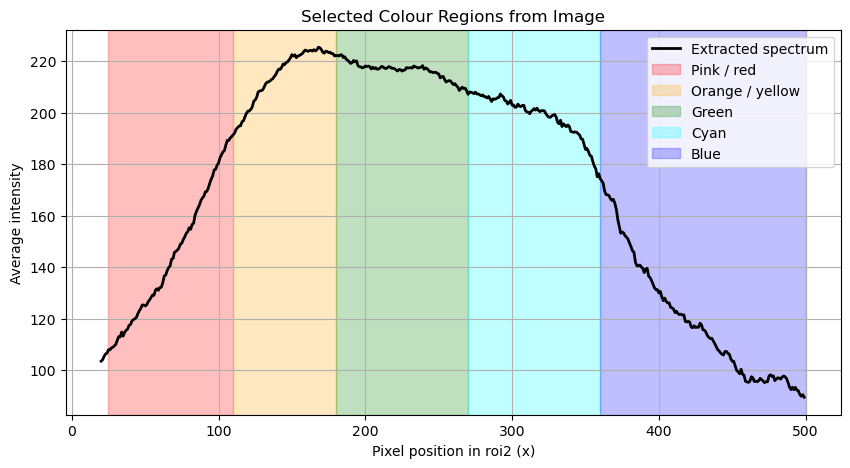

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(x_pixels, spectrum_1d, color="black", linewidth=2, label="Extracted spectrum")

# Coloured regions
plt.axvspan(25, 110, color="red", alpha=0.25, label="Pink / red")
plt.axvspan(110, 180, color="orange", alpha=0.25, label="Orange / yellow")
plt.axvspan(180, 270, color="green", alpha=0.25, label="Green")
plt.axvspan(270, 360, color="cyan", alpha=0.25, label="Cyan")
plt.axvspan(360, 500, color="blue", alpha=0.25, label="Blue")

plt.xlabel("Pixel position in roi2 (x)")
plt.ylabel("Average intensity")
plt.title("Selected Colour Regions from Image")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
pink_red_start, pink_red_end = 25, 110
orange_yellow_start, orange_yellow_end = 110, 180
green_start, green_end = 180, 270
cyan_start, cyan_end = 270, 360
blue_start, blue_end = 360, 500

pink_red_center = (pink_red_start + pink_red_end) / 2
orange_yellow_center = (orange_yellow_start + orange_yellow_end) / 2
green_center = (green_start + green_end) / 2
cyan_center = (cyan_start + cyan_end) / 2
blue_center = (blue_start + blue_end) / 2

print("Pink / red center pixel:", pink_red_center)
print("Orange / yellow center pixel:", orange_yellow_center)
print("Green center pixel:", green_center)
print("Cyan center pixel:", cyan_center)
print("Blue center pixel:", blue_center)

Pink / red center pixel: 67.5
Orange / yellow center pixel: 145.0
Green center pixel: 225.0
Cyan center pixel: 315.0
Blue center pixel: 430.0


In [23]:
known_pixels = np.array([67.5, 225.0, 430.0])
known_wavelengths = np.array([650, 530, 470])

In [25]:
calibration_coeffs = np.polyfit(known_pixels, known_wavelengths, 1)

a, b = calibration_coeffs
print("Calibration coefficients:")
print("a =", a)
print("b =", b)

Calibration coefficients:
a = -0.486537612712026
b = 667.1744750614796


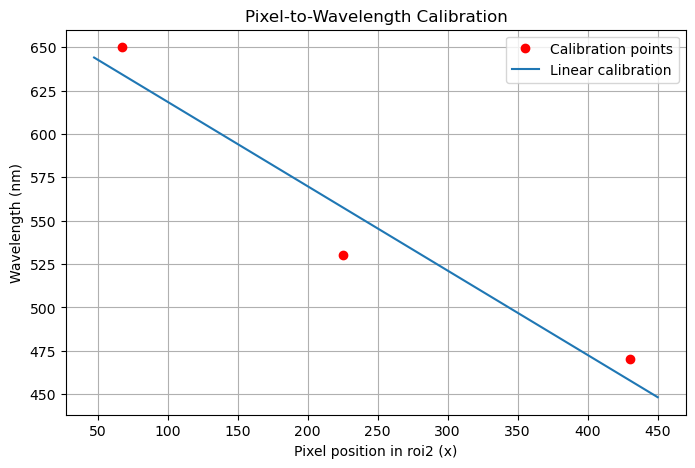

In [27]:
x_fit = np.linspace(min(known_pixels) - 20, max(known_pixels) + 20, 300)
lambda_fit = np.polyval(calibration_coeffs, x_fit)

plt.figure(figsize=(8, 5))
plt.plot(known_pixels, known_wavelengths, "ro", label="Calibration points")
plt.plot(x_fit, lambda_fit, label="Linear calibration")
plt.xlabel("Pixel position in roi2 (x)")
plt.ylabel("Wavelength (nm)")
plt.title("Pixel-to-Wavelength Calibration")
plt.legend()
plt.grid(True)
plt.show()

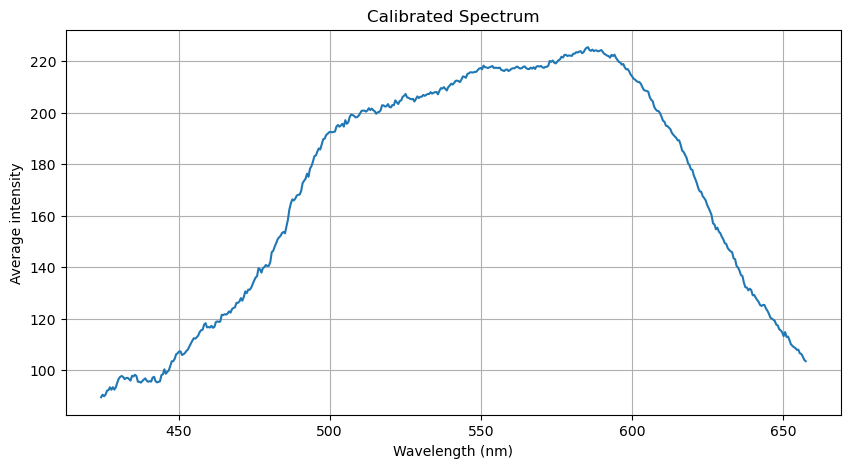

In [29]:
wavelength_axis = np.polyval(calibration_coeffs, x_pixels)

plt.figure(figsize=(10, 5))
plt.plot(wavelength_axis, spectrum_1d)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Average intensity")
plt.title("Calibrated Spectrum")
plt.grid(True)
plt.show()

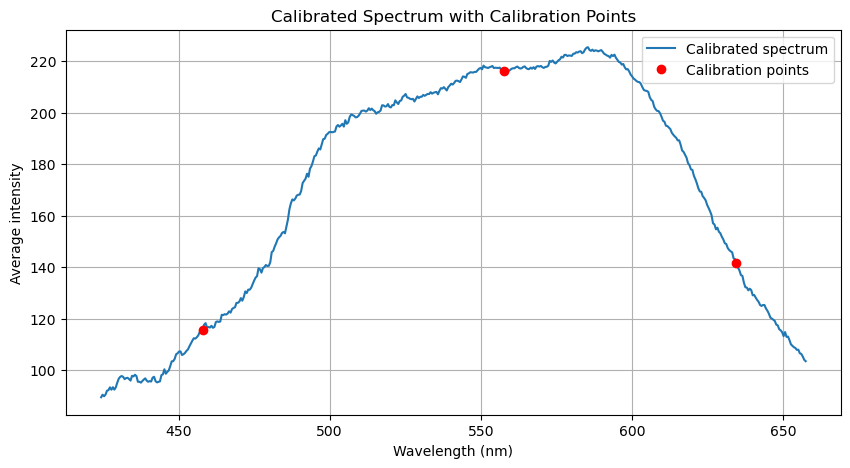

In [31]:
calibration_wavelengths = np.polyval(calibration_coeffs, known_pixels)
calibration_intensities = np.interp(known_pixels, x_pixels, spectrum_1d)

plt.figure(figsize=(10, 5))
plt.plot(wavelength_axis, spectrum_1d, label="Calibrated spectrum")
plt.plot(calibration_wavelengths, calibration_intensities, "ro", label="Calibration points")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Average intensity")
plt.title("Calibrated Spectrum with Calibration Points")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
np.save("calibration_coeffs.npy", calibration_coeffs)
print("Calibration coefficients saved.")

Calibration coefficients saved.


Loaded calibration coefficients: [-4.86537613e-01  6.67174475e+02]


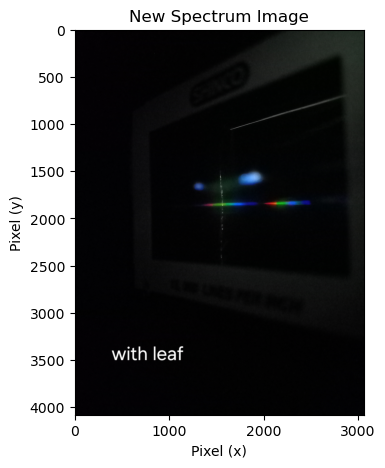

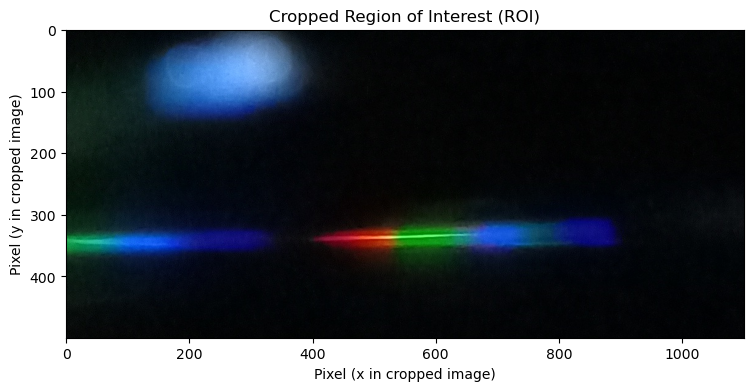

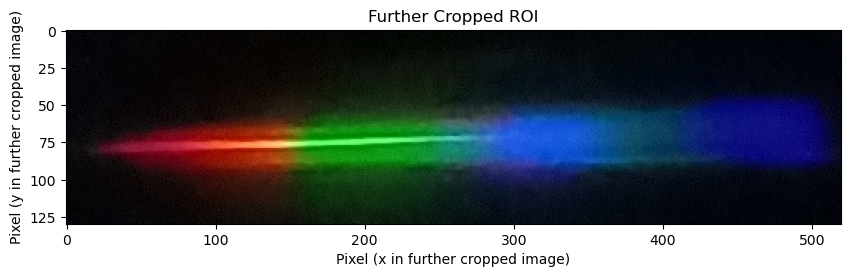

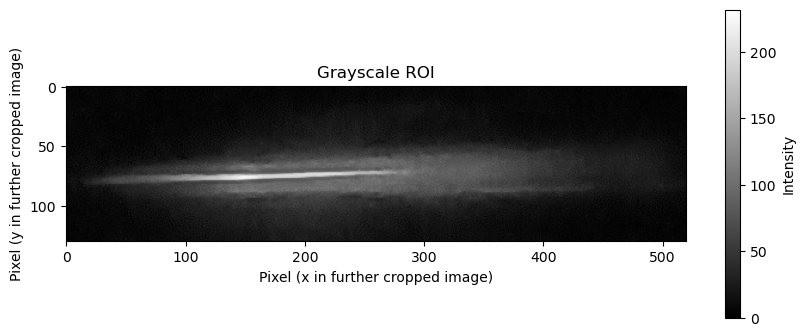

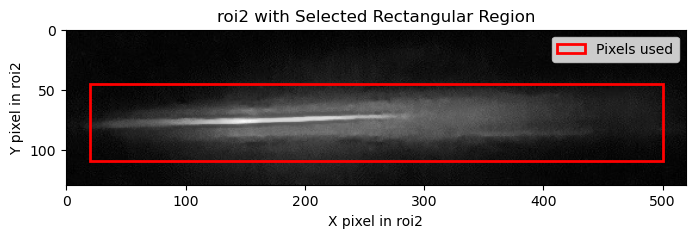

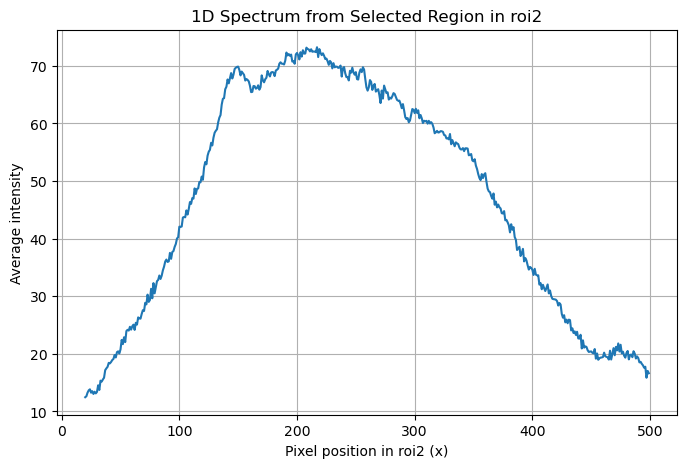

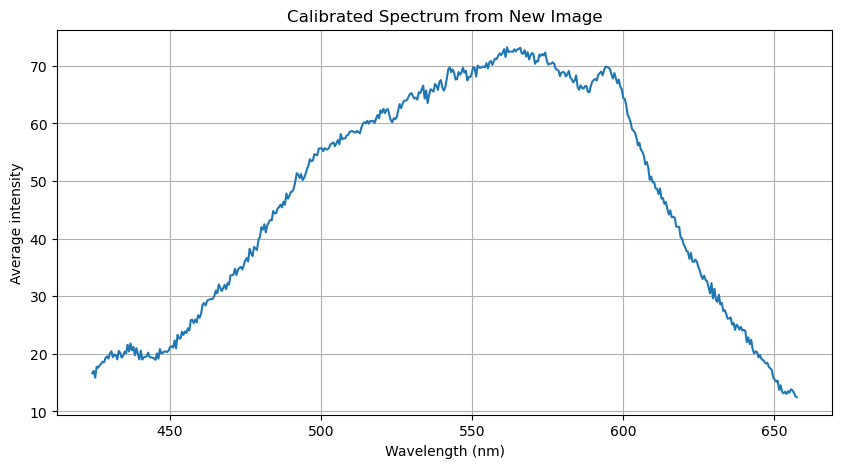

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Load saved calibration coefficients
loaded_coeffs = np.load("calibration_coeffs.npy")
print("Loaded calibration coefficients:", loaded_coeffs)

# --------------------------------------------------
# 1. Load a new image
# --------------------------------------------------
new_image_path = "with_leaf2.jpg"   # change this to your new filename

new_image_bgr = cv2.imread(new_image_path)

if new_image_bgr is None:
    raise FileNotFoundError(f"Could not load image: {new_image_path}")

new_image_rgb = cv2.cvtColor(new_image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))
plt.imshow(new_image_rgb)
plt.title("New Spectrum Image")
plt.xlabel("Pixel (x)")
plt.ylabel("Pixel (y)")
plt.show()

# --------------------------------------------------
# 2. Apply the same first crop
# --------------------------------------------------
x_start = 1600
x_end   = 2700
y_start = 1500
y_end   = 2000

roi = new_image_rgb[y_start:y_end, x_start:x_end]

plt.figure(figsize=(12, 4))
plt.imshow(roi)
plt.title("Cropped Region of Interest (ROI)")
plt.xlabel("Pixel (x in cropped image)")
plt.ylabel("Pixel (y in cropped image)")
plt.show()

# --------------------------------------------------
# 3. Apply the same second crop
# --------------------------------------------------
x2_start = 380
x2_end   = 900
y2_start = 260
y2_end   = 390

roi2 = roi[y2_start:y2_end, x2_start:x2_end]

plt.figure(figsize=(10, 4))
plt.imshow(roi2)
plt.title("Further Cropped ROI")
plt.xlabel("Pixel (x in further cropped image)")
plt.ylabel("Pixel (y in further cropped image)")
plt.show()

# --------------------------------------------------
# 4. Convert to grayscale
# --------------------------------------------------
roi2_gray = cv2.cvtColor(roi2, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(10, 4))
plt.imshow(roi2_gray, cmap="gray")
plt.title("Grayscale ROI")
plt.xlabel("Pixel (x in further cropped image)")
plt.ylabel("Pixel (y in further cropped image)")
plt.colorbar(label="Intensity")
plt.show()

# --------------------------------------------------
# 5. Apply the same extraction box
# --------------------------------------------------
y_start_line = 45
y_end_line   = 110

x_start_line = 20
x_end_line   = 500

selected_region = roi2_gray[y_start_line:y_end_line, x_start_line:x_end_line]
spectrum_1d = np.mean(selected_region, axis=0)
x_pixels = np.arange(x_start_line, x_end_line)

# Show box on grayscale ROI
fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(roi2_gray, cmap="gray")

rect = Rectangle(
    (x_start_line, y_start_line),
    x_end_line - x_start_line,
    y_end_line - y_start_line,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
    label="Pixels used"
)

ax.add_patch(rect)
ax.set_xlabel("X pixel in roi2")
ax.set_ylabel("Y pixel in roi2")
ax.set_title("roi2 with Selected Rectangular Region")
ax.legend()
plt.show()

# Plot extracted intensity against pixel
plt.figure(figsize=(8, 5))
plt.plot(x_pixels, spectrum_1d)
plt.xlabel("Pixel position in roi2 (x)")
plt.ylabel("Average intensity")
plt.title("1D Spectrum from Selected Region in roi2")
plt.grid(True)
plt.show()

# --------------------------------------------------
# 6. Convert x-pixels to wavelength using saved calibration
# --------------------------------------------------
wavelength_axis = np.polyval(loaded_coeffs, x_pixels)

# --------------------------------------------------
# 7. Plot calibrated spectrum
# --------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(wavelength_axis, spectrum_1d)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Average intensity")
plt.title("Calibrated Spectrum from New Image")
plt.grid(True)
plt.show()

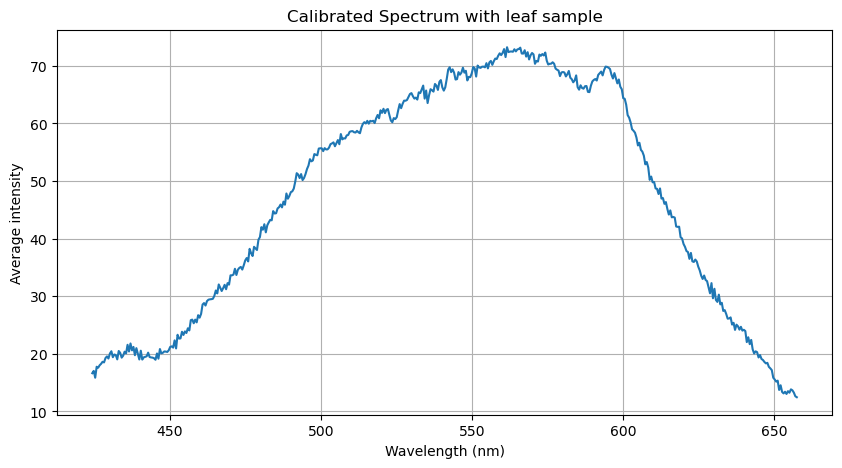

In [41]:
plt.figure(figsize=(10, 5))
plt.plot(wavelength_axis, spectrum_1d)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Average intensity")
plt.title("Calibrated Spectrum with leaf sample")
plt.grid(True)
plt.show()

Loaded calibration coefficients: [-4.86537613e-01  6.67174475e+02]


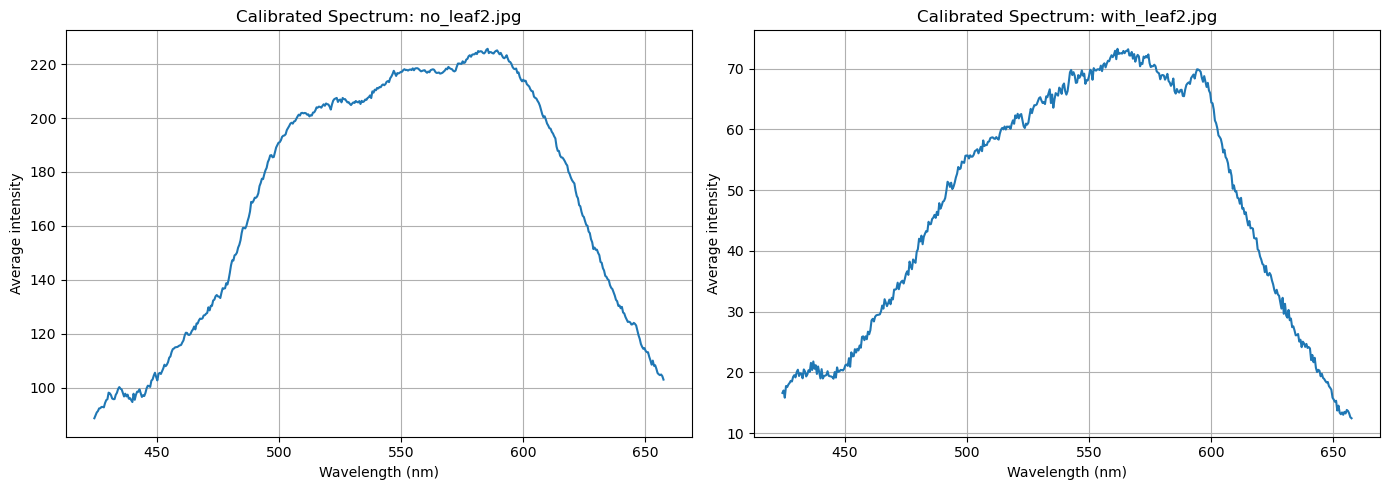

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load saved calibration coefficients
loaded_coeffs = np.load("calibration_coeffs.npy")
print("Loaded calibration coefficients:", loaded_coeffs)

# --------------------------------------------------
# Common settings kept the same
# --------------------------------------------------
x_start = 1600
x_end   = 2700
y_start = 1500
y_end   = 2000

x2_start = 380
x2_end   = 900
y2_start = 260
y2_end   = 390

y_start_line = 45
y_end_line   = 110
x_start_line = 20
x_end_line   = 500

# --------------------------------------------------
# Function to process one image
# --------------------------------------------------
def extract_calibrated_spectrum(image_path, loaded_coeffs):
    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # First crop
    roi = image_rgb[y_start:y_end, x_start:x_end]

    # Second crop
    roi2 = roi[y2_start:y2_end, x2_start:x2_end]

    # Convert to grayscale
    roi2_gray = cv2.cvtColor(roi2, cv2.COLOR_RGB2GRAY)

    # Extract spectrum from selected box
    selected_region = roi2_gray[y_start_line:y_end_line, x_start_line:x_end_line]
    spectrum_1d = np.mean(selected_region, axis=0)
    x_pixels = np.arange(x_start_line, x_end_line)

    # Convert pixels to wavelength
    wavelength_axis = np.polyval(loaded_coeffs, x_pixels)

    return wavelength_axis, spectrum_1d

# --------------------------------------------------
# Load and process two images
# --------------------------------------------------
image_path_1 = "no_leaf2.jpg"
image_path_2 = "with_leaf2.jpg"

wavelength_axis_1, spectrum_1d_1 = extract_calibrated_spectrum(image_path_1, loaded_coeffs)
wavelength_axis_2, spectrum_1d_2 = extract_calibrated_spectrum(image_path_2, loaded_coeffs)

# --------------------------------------------------
# Plot wavelength vs intensity side by side
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))   # removed sharey=True

axes[0].plot(wavelength_axis_1, spectrum_1d_1)
axes[0].set_xlabel("Wavelength (nm)")
axes[0].set_ylabel("Average intensity")
axes[0].set_title(f"Calibrated Spectrum: {image_path_1}")
axes[0].grid(True)

axes[1].plot(wavelength_axis_2, spectrum_1d_2)
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Average intensity")
axes[1].set_title(f"Calibrated Spectrum: {image_path_2}")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [51]:
# Peak intensity
peak1 = np.max(spectrum_1d_1)
peak2 = np.max(spectrum_1d_2)

# Peak wavelength
peak_wavelength1 = wavelength_axis_1[np.argmax(spectrum_1d_1)]
peak_wavelength2 = wavelength_axis_2[np.argmax(spectrum_1d_2)]

# Mean intensity
mean1 = np.mean(spectrum_1d_1)
mean2 = np.mean(spectrum_1d_2)

# Area under curve (fixed: reverse arrays so wavelength increases)
area1 = np.trapz(spectrum_1d_1[::-1], wavelength_axis_1[::-1])
area2 = np.trapz(spectrum_1d_2[::-1], wavelength_axis_2[::-1])

# Percentage changes
peak_change_percent = ((peak2 - peak1) / peak1) * 100
mean_change_percent = ((mean2 - mean1) / mean1) * 100
area_change_percent = ((area2 - area1) / area1) * 100

print("No leaf peak intensity:", peak1)
print("With leaf peak intensity:", peak2)
print("Peak intensity change (%):", peak_change_percent)

print("No leaf peak wavelength:", peak_wavelength1)
print("With leaf peak wavelength:", peak_wavelength2)

print("No leaf mean intensity:", mean1)
print("With leaf mean intensity:", mean2)
print("Mean intensity change (%):", mean_change_percent)

print("No leaf integrated intensity:", area1)
print("With leaf integrated intensity:", area2)
print("Integrated intensity change (%):", area_change_percent)

No leaf peak intensity: 225.69230769230768
With leaf peak intensity: 73.24615384615385
Peak intensity change (%): -67.54601226993864
No leaf peak wavelength: 585.4361561258593
With leaf peak wavelength: 561.5958131029699
No leaf mean intensity: 170.69560897435895
With leaf mean intensity: 46.77467948717949
Mean intensity change (%): -72.59760824063977
No leaf integrated intensity: 39817.30257509699
With leaf integrated intensity: 10916.59037770354
Integrated intensity change (%): -72.58330004370733


In [53]:
# Define wavelength bands
blue_range  = (430, 495)
green_range = (495, 570)
red_range   = (570, 650)

def band_area(wavelength_axis, spectrum, wl_min, wl_max):
    mask = (wavelength_axis >= wl_min) & (wavelength_axis <= wl_max)
    return np.trapz(spectrum[mask], wavelength_axis[mask])

# No leaf
blue1 = band_area(wavelength_axis_1, spectrum_1d_1, *blue_range)
green1 = band_area(wavelength_axis_1, spectrum_1d_1, *green_range)
red1 = band_area(wavelength_axis_1, spectrum_1d_1, *red_range)

# With leaf
blue2 = band_area(wavelength_axis_2, spectrum_1d_2, *blue_range)
green2 = band_area(wavelength_axis_2, spectrum_1d_2, *green_range)
red2 = band_area(wavelength_axis_2, spectrum_1d_2, *red_range)

print("Blue area (no leaf):", blue1)
print("Blue area (with leaf):", blue2)
print("Blue change (%):", ((blue2 - blue1) / blue1) * 100)

print("Green area (no leaf):", green1)
print("Green area (with leaf):", green2)
print("Green change (%):", ((green2 - green1) / green1) * 100)

print("Red area (no leaf):", red1)
print("Red area (with leaf):", red2)
print("Red change (%):", ((red2 - red1) / red1) * 100)

Blue area (no leaf): -8051.602417457712
Blue area (with leaf): -1990.066084290895
Blue change (%): -75.28360218115121
Green area (no leaf): -15455.986304306745
Green area (with leaf): -4795.456929576521
Green change (%): -68.97346545758593
Red area (no leaf): -14727.91645025638
Red area (with leaf): -3857.0156969835225
Red change (%): -73.81153192978373
